# A five-minute tutorial: inner-layer production and dissipation

**Jianou Jiang and Budimir Rosic · Physics of Fluids 38, 095140 (2026)**  
[Read the paper](https://doi.org/10.1063/5.0347368) · [Code and citation](https://github.com/JianouJiang/symbolic-regression-pe-closure)

Compare the recommended symbolic-regression expression with the equilibrium assumption and the M16 asymptotic benchmark. Then estimate dissipation using DNS production. **No training, PySR installation, or CFD simulation is required.**

Choose **Runtime → Run all** in Colab, or **Run → Run All Cells** in Jupyter. A fresh Colab session downloads the versioned public code; the data step downloads one 47 kB table from the original provider.

This is a **training-family illustration**, not a new independent validation. The later dissipation comparison uses DNS production and does not establish performance in a coupled RANS solver.

## 1. Load the published implementation

The code below uses a local clone when available. For a standalone notebook (including Colab), it clones release `v1.0.0` into the working directory. It installs NumPy and Matplotlib only if they are missing.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

roots = [Path.cwd(), *Path.cwd().parents]
repo = next((p for p in roots if (p / "closure/pe_closure.py").is_file()
             and (p / "examples/quickstart.py").is_file()), None)
if repo is None:
    repo = Path.cwd() / "symbolic-regression-pe-closure"
    if not repo.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "v1.0.0",
            "https://github.com/JianouJiang/symbolic-regression-pe-closure.git",
            str(repo),
        ], check=True)
    if not (repo / "examples/quickstart.py").is_file():
        raise RuntimeError("The local tutorial checkout is incomplete; use a fresh notebook directory.")
missing = [name for name in ("numpy", "matplotlib") if importlib.util.find_spec(name) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *missing], check=True)
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import matplotlib.pyplot as plt
from closure.pe_closure import f_pysr, f_m16, valid_domain
from examples.quickstart import load_dns, evaluate, print_metrics, make_figure, SOURCE_URL
print("Ready: published formulas loaded.")

Ready: published formulas loaded.


## 2. Evaluate the closure on your own wall coordinates

The recommended expression is

$$F_{\rm PySR}(y^+)=\frac{\tanh(0.128y^+)}{\tanh(0.053y^+-0.620)+5.78/y^+}.$$

Use it for $1<y^+\leq\min(150,0.3Re_\tau)$ in incompressible, smooth-wall, pressure-driven flow. M16 uses a squared numerator and different coefficients to recover the exact cubic wall exponent. The recommended PySR expression has quadratic leading wall order; M16's asymptotic advantage does not make it the paper's recommended finite-domain predictor.

Mask your coordinates **before** evaluating either formula. Neither expression should be evaluated at $y^+=0$.

In [2]:
yplus = np.array([0.0, 2.0, 5.0, 12.0, 30.0, 60.0, 100.0, 150.0, 200.0])
mask = valid_domain(yplus, re_tau=550)
y = yplus[mask]
print("Excluded coordinates:", yplus[~mask])
print(" y+      PySR      M16")
for yp, fp, fm in zip(y, f_pysr(y), f_m16(y)):
    print(f"{yp:5.1f}  {fp:8.4f} {fm:8.4f}")

Excluded coordinates: [  0. 200.]
 y+      PySR      M16
  2.0    0.1037   0.0427
  5.0    0.6930   0.6411
 12.0    1.8314   1.8023
 30.0    1.0613   1.1020
 60.0    0.9221   0.9627
100.0    0.9455   0.9721
150.0    0.9629   0.9811


## 3. Fetch one small, traceable DNS example

We use the Lee–Moser channel at nominal `Re_tau = 550`. The original header gives the actual value **543.496**. The loader downloads and caches the original table, verifies its SHA-256 checksum against the file used in the paper's audit, and reads wall distance, production, and **positive** dissipation from the documented columns.

The data are downloaded from their original provider and are not redistributed or relicensed with this code. Please cite **Lee and Moser, Journal of Fluid Mechanics 774, 395–415 (2015), [doi:10.1017/jfm.2015.268](https://doi.org/10.1017/jfm.2015.268)** when using these DNS data.

Subsequent runs use the cache. For offline use, pass `load_dns(data_path=Path("/path/to/LM_Channel_0550_RSTE_k_prof.dat"))`. A failed download or changed checksum stops the example.

In [3]:
dns = load_dns()
print("Source:", SOURCE_URL)
print("Re_tau:", dns["re_tau"])
print("Native wall-normal points:", len(dns["yplus"]))

Source: https://turbulence.oden.utexas.edu/channel2015/data/LM_Channel_0550_RSTE_k_prof.dat
Re_tau: 543.496
Native wall-normal points: 192


## 4. Compare the ratio and the dissipation estimate

The left panel compares $\mathcal{P}/\varepsilon$ on the stated closure domain. The right panel compares DNS dissipation with $\varepsilon_{\rm eq}=\mathcal{P}_{\rm DNS}$ and $\varepsilon_F=\mathcal{P}_{\rm DNS}/F(y^+)$ on **$5<y^+<80$**. Every model uses the same native DNS points; there is no interpolation or refitting.

Lee–Moser channel: Re_tau = 543.496
Training-family illustration; not a new independent validation.

Production/dissipation ratio: 1 < y+ <= min(150, 0.3 Re_tau), epsilon+ > 1e-8 (84 points)
Model                                  RMSE           R2
Equilibrium                      0.39085120  -0.00000536
PySR (recommended)               0.03698647   0.99104501
M16 (asymptotic benchmark)       0.04742610   0.98527639

Dissipation using DNS production: 5 < y+ < 80, within the closure domain, epsilon+ > 1e-8 (49 points)
Model                                  RMSE           R2
Equilibrium                      0.04634996  -0.40183800
PySR (recommended)               0.00249884   0.99592548
M16 (asymptotic benchmark)       0.00273066   0.99513443

PySR dissipation RMSE reduction vs equilibrium: 94.61%
A-priori diagnostic using DNS production; not a coupled RANS result.


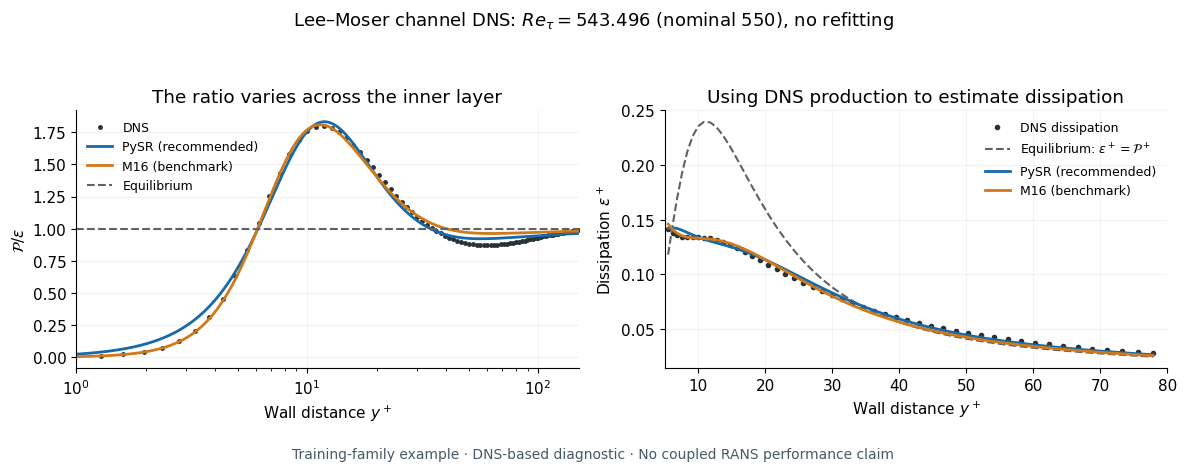

In [4]:
results = evaluate(dns)
print_metrics(results)
figure = make_figure(dns)
plt.show()

## 5. Check against the paper's existing audit

This small example should reproduce the stored nominal-550 channel diagnostic: **49 points**, equilibrium RMSE **0.0463499581**, PySR RMSE **0.0024988421**, and **94.61%** RMSE reduction. This agreement checks the implementation, source table, signs, and evaluation mask; it does not create a new validation result.

In [5]:
import json
reference = json.loads((repo / "audit/CLEAN_ROOM_NUMERICAL_AUDIT.json").read_text())
reference = reference["dissipation_diagnostic"]["channel"]["550"]
actual = results["dissipation_diagnostic"]
assert actual["n"] == reference["n"]
np.testing.assert_allclose(actual["models"]["Equilibrium"]["RMSE"],
                           reference["RMSE_equilibrium"], rtol=1e-12)
np.testing.assert_allclose(actual["models"]["PySR (recommended)"]["RMSE"],
                           reference["RMSE_corrected"], rtol=1e-12)
np.testing.assert_allclose(actual["models"]["PySR (recommended)"]["R2"],
                           reference["R2_corrected"], rtol=1e-12)
print("Matches the paper's existing audit.")

Matches the paper's existing audit.


## Applying the result

For your own positive, in-domain wall coordinates, call `f_pysr(yplus)`. If production is available, the corresponding algebraic dissipation estimate is `production / f_pysr(yplus)` using consistent units. Inputs derived from an imperfect RANS solution introduce errors that this DNS-based demonstration does not test.

The closure deteriorates under strong adverse pressure gradients, does not model the outer wake, and fails out of domain on plane Couette flow. For the paper's comparison across external sources, see [FORMULA_DECISION.md](https://github.com/JianouJiang/symbolic-regression-pe-closure/blob/v1.0.0/FORMULA_DECISION.md).

**Cite the closure:** J. Jiang and B. Rosic, “Combining symbolic regression and turbulence physics to develop a compact inner-layer production–dissipation closure,” *Physics of Fluids* **38**, 095140 (2026), [doi:10.1063/5.0347368](https://doi.org/10.1063/5.0347368).

**Cite the DNS data:** M. Lee and R. D. Moser, *Journal of Fluid Mechanics* **774**, 395–415 (2015), [doi:10.1017/jfm.2015.268](https://doi.org/10.1017/jfm.2015.268).